In [1]:
import mysql.connector
from mysql.connector import errorcode
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [33]:
config = {    
  'user': 'root',
  'password': 'mo210916',  
  'host': 'localhost',
  'database': 'basketball_stats'
}

DB_NAME = 'basketball_stats' 

print("Connection parameters defined.")

Connection parameters defined.


In [34]:
try:
    
    cnxn = mysql.connector.connect(**config)
    cursor = cnxn.cursor()
    print("✅ Connected to basketball_stats database.")


    # cnxn.commit()
    # print("✅ SQL script executed successfully.")

except mysql.connector.Error as err:
    print(f"❌ Connection or execution error: {err}")

finally:
    if 'cnxn' in locals() and cnxn.is_connected():
        cursor.close()
        cnxn.close()
        print("✅ Connection closed.")

✅ Connected to basketball_stats database.
✅ Connection closed.



<ul dir="rtl" style="font-family: vazir; font-size: medium; line-height: 200%; text-align: justify;">
فرضیه اول
  <li><strong>فرضیه صفر (H<sub>0</sub>):</strong> میانگین چابکی در ۲۰ بازیکن اول هر فصل در دوره جدید تفاوتی با گذشته ندارد </li>
  <li><strong>فرضیه جایگزین (H<sub>1</sub>):</strong>میانگین چابکی در ۲۰ بازیکن اول هر فصل  در دوره جدید بیشتر از گذشته است</li>
</ul>

<ul dir="rtl" style="font-family: vazir; font-size: medium; line-height: 200%; text-align: justify;">
نتایج:
  <li><strong>چون p-value = 0.506، نمی‌ توانیم فرض صفر را رد کنیم. </li>
  <li><strong>یعنی شواهد آماری کافی برای اثبات افزایش چابکی در دوره جدید وجود ندارد.</li>
</ul>


In [47]:
#فرضیه اول
try:
    
    with mysql.connector.connect(**config) as cnxn:
        query_past = """

        select
            ps.season,
            p.player_id,
            p.player_name,
            ps.rank,
            (p.height_cm / p.weight_kg) as agility,
            'Past' as group_lable
        from player_stats ps
        join players p on p.player_id = ps.player_id
        where ps.season in (2021, 2022) and ps.rank <= 20
            """

        query_new = """

        select
            ps.season,
            p.player_id,
            p.player_name,
            ps.rank,
            (p.height_cm / p.weight_kg) as agility,
            'New' as group_lable
        from player_stats ps
        join players p on p.player_id = ps.player_id
        where ps.season in (2023, 2024) and ps.rank <= 20;

            """
        df_past = pd.read_sql(query_past, cnxn)
        df_new = pd.read_sql(query_new, cnxn)

        # display(df_past)
        # display(df_new)
        
        dataf_test1 = pd.concat([df_past, df_new], ignore_index=True)


except mysql.connector.Error as err:
    print(f"❌ Error: {err}")


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_7796\1311359734.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_past = pd.read_sql(query_past, cnxn)
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_7796\1311359734.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_new = pd.read_sql(query_new, cnxn)


c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


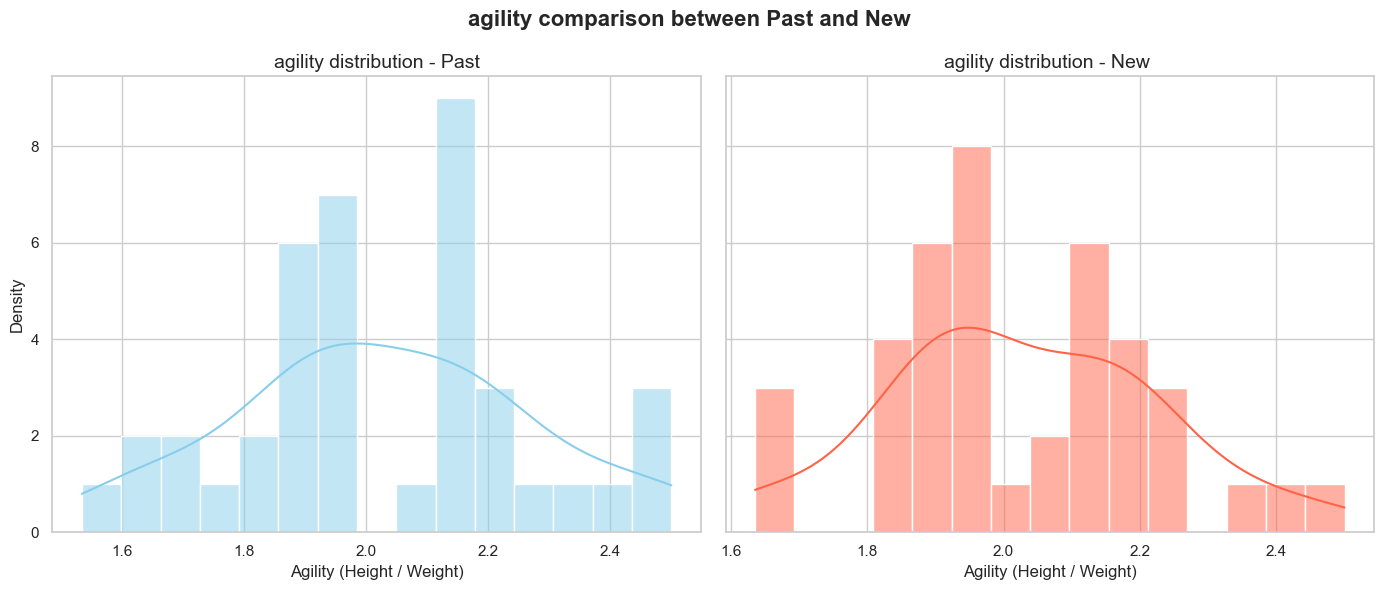

In [51]:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.histplot( data=df_past, x="agility", bins=15, kde=True, color="skyblue", ax=axes[0])
axes[0].set_title("agility distribution - Past", fontsize=14)
axes[0].set_xlabel("Agility (Height / Weight)")
axes[0].set_ylabel("Density")

sns.histplot( data=df_new, x="agility", bins=15, kde=True,color="tomato", ax=axes[1])
axes[1].set_title("agility distribution - New ", fontsize=14)
axes[1].set_xlabel("Agility (Height / Weight)")
axes[1].set_ylabel("Density")

plt.suptitle("agility comparison between Past and New ", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


In [52]:
shapiro_past = stats.shapiro(df_past['agility'])
print(f"shapiro test (Past):")
print(f"statistic = {shapiro_past.statistic:.3f}, p-value = {shapiro_past.pvalue:.3f}")

shapiro_new = stats.shapiro(df_new['agility'])
print(f"shapiro test (New):")
print(f"statistic = {shapiro_new.statistic:.3f}, p-value = {shapiro_new.pvalue:.3f}")

shapiro test (Past):
statistic = 0.974, p-value = 0.483
shapiro test (New):
statistic = 0.976, p-value = 0.560


In [53]:
t_test = stats.ttest_ind( df_new["agility"] , df_past["agility"],  equal_var=False, alternative='greater' )
print(f"T-statistic = {t_test.statistic:.3f}, p-value = {t_test.pvalue:.3f}")

T-statistic = -0.015, p-value = 0.506


<ul dir="rtl" style="font-family: vazir; font-size: medium; line-height: 200%; text-align: justify;">
فرضیه دوم
  <li><strong>فرضیه صفر (H<sub>0</sub>):</strong> میانگین توانایی ذاتی بازیکنان تیم قهرمان در دو فصل اخیر تفاوتی با دو فصل قبل ار آن ندارد</li>
  <li><strong>فرضیه جایگزین (H<sub>1</sub>):</strong>میانگین توانایی ذاتی بازیکنان تیم قهرمان در دو فصل اخیر بیشتر از دو فصل قبل از آن است</li></li>
</ul>


<ul dir="rtl" style="font-family: vazir; font-size: medium; line-height: 200%; text-align: justify;">
نتایج:
  <li><strong>چون p-value = 1.00، نمی‌ توانیم فرض صفر را رد کنیم. </li>
  <li><strong>یعنی شواهد آماری کافی برای اثبات افزایش توانایی ذاتی در بازیکنان دو فصل اخیر وجود ندارد.</li>
</ul>


In [54]:
#فرضیه دوم
try:
    
    with mysql.connector.connect(**config) as cnxn:
        query_past_season = """
        select
            r.season,
            p.player_id,
            p.player_name,
            p.experience,
            p.age,
            (p.experience / p.age) as intrinsic_ability,
            'Past' as group_label
        from season_stats s
        join team_lookup t on s.champion_name = t.team_name
        join rosters r on r.team_id = t.team_id and r.season = s.season
        join players p on p.player_id = r.player_id
        where s.season in (2022, 2023) and p.experience is not null;
        
            """

        query_new_season = """
        select
            r.season,
            p.player_id,
            p.player_name,
            p.experience,
            p.age,
            (p.experience / p.age) as intrinsic_ability,
            'New' as group_label
        from season_stats s
        join team_lookup t on s.champion_name = t.team_name
        join rosters r on r.team_id = t.team_id and r.season = s.season
        join players p on p.player_id = r.player_id
        where s.season in (2024, 2025) and p.experience is not null;
     
            """
        df_past_season = pd.read_sql(query_past_season, cnxn)
        df_new_season = pd.read_sql(query_new_season, cnxn)
        
        # display(df_past_season)
        # display(df_new_season)
        
        dataf_test2 = pd.concat([df_past_season, df_new_season], ignore_index=True)
        

except mysql.connector.Error as err:
    print(f"❌ Error: {err}")


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_7796\1488692511.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_past_season = pd.read_sql(query_past_season, cnxn)
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_7796\1488692511.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_new_season = pd.read_sql(query_new_season, cnxn)


c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


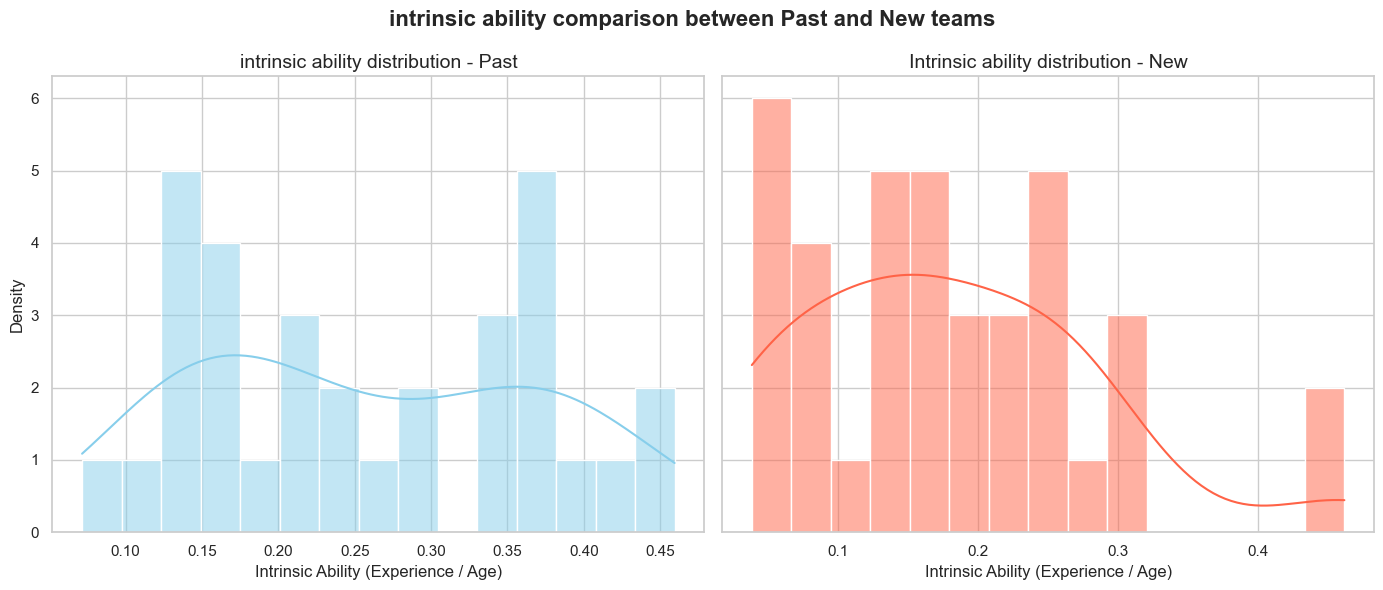

In [55]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.histplot(data=df_past_season, x="intrinsic_ability", bins=15, kde=True, color="skyblue", ax=axes[0])
axes[0].set_title("intrinsic ability distribution - Past", fontsize=14)
axes[0].set_xlabel("Intrinsic Ability (Experience / Age)")
axes[0].set_ylabel("Density")

sns.histplot(data=df_new_season, x="intrinsic_ability", bins=15, kde=True, color="tomato", ax=axes[1])
axes[1].set_title("Intrinsic ability distribution - New", fontsize=14)
axes[1].set_xlabel("Intrinsic Ability (Experience / Age)")
axes[1].set_ylabel("Density")

plt.suptitle("intrinsic ability comparison between Past and New teams", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


In [56]:
shapiro_past = stats.shapiro(df_past_season['intrinsic_ability'])
print(f"shapiro test (Past):")
print(f"statistic = {shapiro_past.statistic:.3f}, p-value = {shapiro_past.pvalue:.3f}")

shapiro_new = stats.shapiro(df_new_season['intrinsic_ability'])
print(f"shapiro test (New):")
print(f"statistic = {shapiro_new.statistic:.3f}, p-value = {shapiro_new.pvalue:.3f}")

shapiro test (Past):
statistic = 0.940, p-value = 0.073
shapiro test (New):
statistic = 0.930, p-value = 0.020


In [57]:
def Yeo_johnson(df, column_name, label):
  
    transformed_data, lambda_val = stats.yeojohnson(df[column_name])
    
    stat, p_value = stats.shapiro(transformed_data)
    print(f"Yeo-Johnson transformation for {label}:")
    print(f"λ = {lambda_val:.3f}, shapiro p-value = {p_value:.3f}")
    
    fig, ax = plt.subplots(figsize=(8, 6))
    stats.probplot(transformed_data, dist="norm", plot=ax)
    ax.set_title(f'QQ Plot for "{label}" after Yeo-Johnson\nshapiro p = {p_value:.3f}')
    plt.tight_layout()
    plt.show()
    
    return transformed_data



Yeo-Johnson transformation for Past:
λ = -0.589, shapiro p-value = 0.095


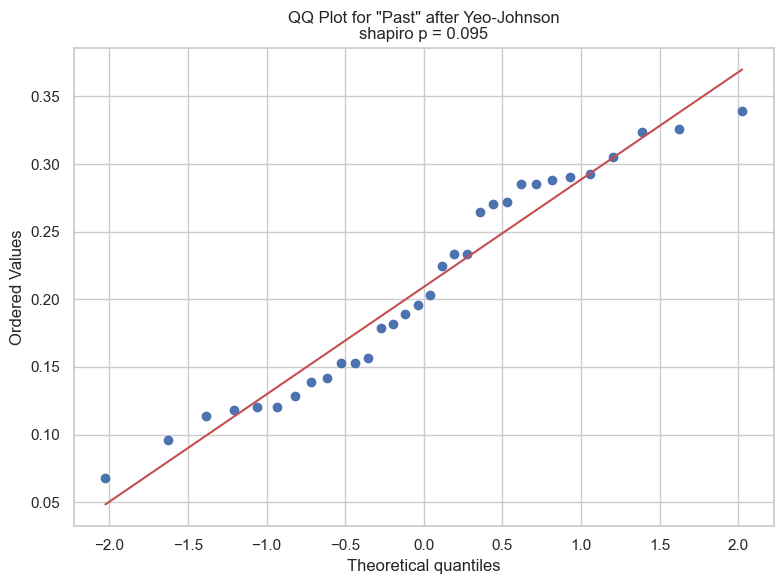

Yeo-Johnson transformation for New :
λ = -2.418, shapiro p-value = 0.152


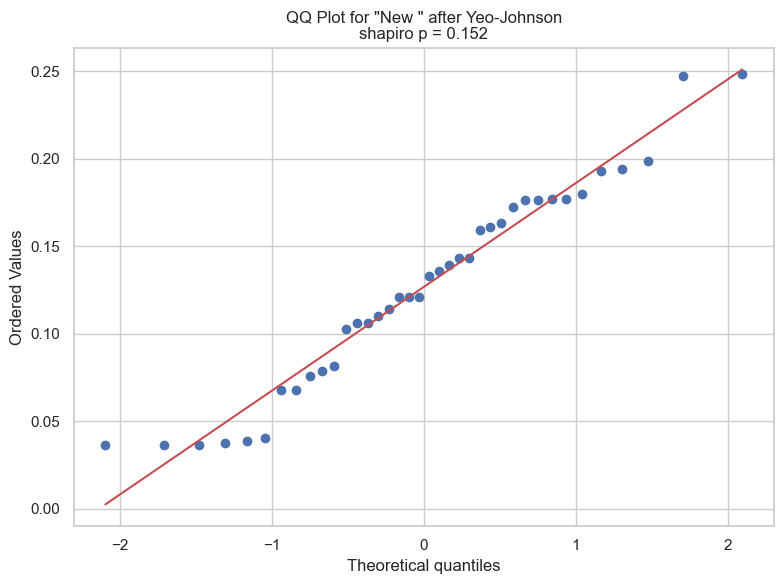

In [58]:
df_past_season["intrinsic_ability_transforme"] = Yeo_johnson(df_past_season, "intrinsic_ability", "Past")
df_new_season["intrinsic_ability_transforme"] = Yeo_johnson(df_new_season, "intrinsic_ability", "New ")


In [59]:
t_test = stats.ttest_ind( df_new_season["intrinsic_ability_transforme"] , df_past_season["intrinsic_ability_transforme"],  equal_var=False, alternative='greater' )
print(f"T-statistic = {t_test.statistic:.3f}, p-value = {t_test.pvalue:.3f}")

T-statistic = -4.918, p-value = 1.000
